## Part II: Reply Homophily Analysis

#### Name: Tracy Chen, Hayley Shin (Group No: 7)

## II.1 Data Collection
Write code to collect replies to senator posts. To ensure sufficient data for gender comparisons, collect reply data for at least 5 female senators and at least 5 male senators (the dataset contains 14 female and 28 male senators), uniformly at random. If you can, take the time to run your code long enough to collect data for all the senators.

For each senator in your sample:

1. Fetch their posts from the last 7 days using getAuthorFeed
2. For each post with replies, fetch the reply thread using getPostThread
3. Extract replier information (handle, display name, timestamp) and post metadata (reply count, for understanding sampling)
4. Save the data (in JSON) for each senator

Important: Save the post’s total replyCount field along with the replies you captured. This lets you determine what fraction of replies you collected for each post, which is essential for the timing analysis.

In [ ]:
# import
import json
import time
import gzip
from datetime import datetime, timezone, timedelta
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd))
import bluesky_helpers as bh
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

In [2]:
# load senator data
senators = bh.load_senators('senators_bluesky.csv')
senators[0:5]

[{'name': 'Tammy Baldwin',
  'handle': 'baldwin.senate.gov',
  'party': 'D',
  'state': 'WI',
  'gender': 'F'},
 {'name': 'Patty Murray',
  'handle': 'murray.senate.gov',
  'party': 'D',
  'state': 'WA',
  'gender': 'F'},
 {'name': 'Maria Cantwell',
  'handle': 'cantwell.senate.gov',
  'party': 'D',
  'state': 'WA',
  'gender': 'F'},
 {'name': 'Mark Warner',
  'handle': 'markwarner.bsky.social',
  'party': 'D',
  'state': 'VA',
  'gender': 'M'},
 {'name': 'Tim Kaine',
  'handle': 'kaine.senate.gov',
  'party': 'D',
  'state': 'VA',
  'gender': 'M'}]

In [ ]:
# make functions for collecting data
# 1) fetch senator's posts from the last 7 days
def collect_posts(handle, days=7):
    start_date = datetime.now(timezone.utc) - timedelta(days=days)
    all_posts = []
    cursor = None

    while True:
        feed_data = bh.get_author_feed(handle, limit=100, cursor=cursor)
        time.sleep(random.uniform(1.0, 2.5))
        
        # if API failed -> break
        if not feed_data:
            print(f"API failed for {handle}")
            break

        # if no 'feed' key -> break
        if 'feed' not in feed_data:
            print(f"Missing 'feed' key for {handle}")
            break
        
        # get feed posts
        feed_posts = feed_data.get('feed', [])

        # if feed is empty -> break
        if not feed_posts:
            break

        # if post if older than start_date -> break
        # (b/c we are using posts from the last 7 days)
        old_post = False
        for post in feed_posts:
            tmp = post.get('post', {})
            record = tmp.get('record', {})
            created_at = record.get('createdAt')
            # skip the post if there is no date
            if not created_at:
                continue
            created_at = datetime.fromisoformat(created_at.replace('Z', '+00:00'))
            # break if post is older than start_date
            if created_at < start_date:
                old_post = True
                break
            all_posts.append(post)
        if old_post:
            break

        # go to next page
        cursor = feed_data.get('cursor')

        # break if there is no more page
        if not cursor:
            break
    
    return all_posts


# 2) extract replier information (handle, display name, timestamp, etc.)
def extract_replier_info(thread):

    replier_info = []
    
    # get replies
    thread_tmp = thread['thread']
    thread_replies = thread_tmp.get('replies', []) or []   # if there is no api response or 'thread' return empty list

    for r in thread_replies:
        
        # skip if blocked or not found
        if r.get('$type') != 'app.bsky.feed.defs#threadViewPost':
            continue

        post = r.get('post', {})
        author = post.get('author', {})
        record = post.get('record', {})

        reply_info = {
            'handle': author.get('handle', ''),               # ID
            'displayName': author.get('displayName', ''),     # name
            'timestamp': record.get('createdAt', None),        # time
            'text': record.get('text', ''),                   # text (optional for II.4 Reply Timing Analysis)
            'likeCount': post.get('likeCount', 0)             # num like (optional for II.4 Reply Timing Analysis)
        }

        replier_info.append(reply_info)

    return replier_info

# 3) fetch the reply thread for each post
def collect_replies(single_post):
    post = single_post.get('post', {})
    record = post.get('record', {})
    uri = post.get('uri')
    reply_count = post.get('replyCount', 0)

    post_info = {
        'uri': uri,
        'createdAt': record.get('createdAt'),
        'text': record.get('text', ''),
        'likeCount': post.get('likeCount', 0),
        'repostCount': post.get('repostCount', 0),
        'replies': [],
        'repliesCollected': 0,
        'replyCount': reply_count
    }

    # collect replies if the post has replies
    if uri and reply_count > 0:
        reply_thread = bh.get_post_thread(uri)
        time.sleep(random.uniform(1.0, 2.5))

        if reply_thread:
            replies = extract_replier_info(reply_thread)
            post_info['replies'] = replies
            post_info['repliesCollected'] = len(replies)
        else:
            print(f"Failed to collect replies for post: {uri}")
            post_info['replyError'] = True
    
    return post_info

# 4) collect replies to all senator's post from the last 7 days
def collect_posts_and_replies(senator, days=7):
    result = {
        'senator': senator,
        'collectMeta': {
            'collectedAt': datetime.now(timezone.utc).isoformat(),
            'daysLookback': days
        },
        'posts': []
    }

    # 1. collect posts from last N days
    feed_posts = collect_posts(senator['handle'], days=days)

    # 2. collect replies for each posts
    for i in feed_posts:
        post_info = collect_replies(i)
        result['posts'].append(post_info)
    
    # print data collection result
    tot_posts_collected = len(result['posts'])
    tot_replies_collected = sum(p['repliesCollected'] for p in result['posts'])
    tot_replies_count = sum(p['replyCount'] for p in result['posts'])
    percent = tot_replies_collected/tot_replies_count*100 if tot_replies_count > 0 else 0
    print(f"Collected: {senator['name']} \n  {tot_posts_collected} posts, {tot_replies_collected} replies, {percent:.1f}% of total reply count")

    # save
    filename = f"PartII1_reply_{senator['name'].replace(' ', '_')}.json"
    bh.save_json(result, filename)

    return result

In [ ]:
# collect posts and replies for all senators
all_senators_replies = []
for senator in tqdm(senators):
    senator_data = collect_posts_and_replies(senator, days=7)
    all_senators_replies.append(senator_data)
    time.sleep(random.uniform(0.5, 1.5))

# save all senators' reply data
bh.save_json(all_senators_replies, 'PartII1_reply_allSenators.json')

  0%|          | 0/42 [00:00<?, ?it/s]

Collected: Tammy Baldwin 
  9 posts, 88 replies, 95.7% of total reply count


  2%|▏         | 1/42 [00:20<13:54, 20.35s/it]

Collected: Patty Murray 
  29 posts, 664 replies, 98.4% of total reply count


  5%|▍         | 2/42 [01:22<29:50, 44.77s/it]

...

 95%|█████████▌| 40/42 [21:01<00:53, 26.85s/it]

Collected: Mark Kelly 
  12 posts, 661 replies, 98.1% of total reply count


 98%|█████████▊| 41/42 [21:27<00:26, 26.51s/it]

Collected: Ruben Gallego 
  7 posts, 62 replies, 100.0% of total reply count


100%|██████████| 42/42 [21:41<00:00, 30.99s/it]


## II.2 Gender Inference
**detailed Gender Inference code is in Part2/bluesky_helpers.py**

Make an inference about the gender of repliers from their display names. Using the SSA baby name data. For instance:

1. Extract a likely first name from each display name
2. Look up the name’s historical gender distribution
3. Classify as female if >60% of registrations are female, male if >60% are male, otherwise unknown

In [ ]:
# load SSA baby name data
name_data = bh.load_name_data(female_file='female_names.tsv.gz', male_file='male_names.tsv.gz')

# load posts and replies data for all senator
with open('PartII1_reply_allSenators.json', 'r') as f:
    all_senators_replies = json.load(f)

In [ ]:
# variables for check the fraction of repliers we can classify
total_replies = 0
gender_counts = {'F': 0, 'M': 0, 'U': 0}
empty_display_names = 0

# conduct gender inference to all replies
for senator in tqdm(all_senators_replies):
    for post in senator['posts']:
        for reply in post['replies']:
            total_replies += 1
            gender = bh.infer_gender(reply['displayName'], name_data)
            reply['inferred_gender'] = gender
            gender_counts[gender] += 1

            # count the number of empty display names
            if not reply['displayName']:
                empty_display_names += 1

# save all senators' reply data + gender inference
bh.save_json(all_senators_replies, 'PartII2_reply_allSenators_add_gender.json')

100%|██████████| 42/42 [00:00<00:00, 1541.17it/s]


In [5]:
# check results and stats
gender_inferred_counts = gender_counts['F'] + gender_counts['M']
gender_inferred_percent = (gender_inferred_counts / total_replies) * 100
female_inferred_percent = (gender_counts['F'] / total_replies) * 100
male_inferred_percent = (gender_counts['M'] / total_replies) * 100
unknown_percent = (gender_counts['U'] / total_replies) * 100
unknown_empty_percent = (empty_display_names / total_replies) * 100
print(f"Total Replies Collected: {total_replies:,}")
print(f"Number of Repliers We Can Classify: {gender_inferred_counts:,} ({gender_inferred_percent:.3f}%)")
print(f"   - Female: {gender_counts['F']:,} ({female_inferred_percent:.3f}%)")
print(f"   - Male  : {gender_counts['M']:,} ({male_inferred_percent:.3f}%)")
print(f"Number of Repliers We Can NOT Classify: {gender_counts['U']:,} ({unknown_percent:.3f}%)")
print(f"   - Empty displayName : {empty_display_names:,} ({unknown_empty_percent:.3f}%)")

Total Replies Collected: 13,056
Number of Repliers We Can Classify: 4,599 (35.225%)
   - Female: 1,794 (13.741%)
   - Male  : 2,805 (21.484%)
Number of Repliers We Can NOT Classify: 8,457 (64.775%)
   - Empty displayName : 3,290 (25.199%)


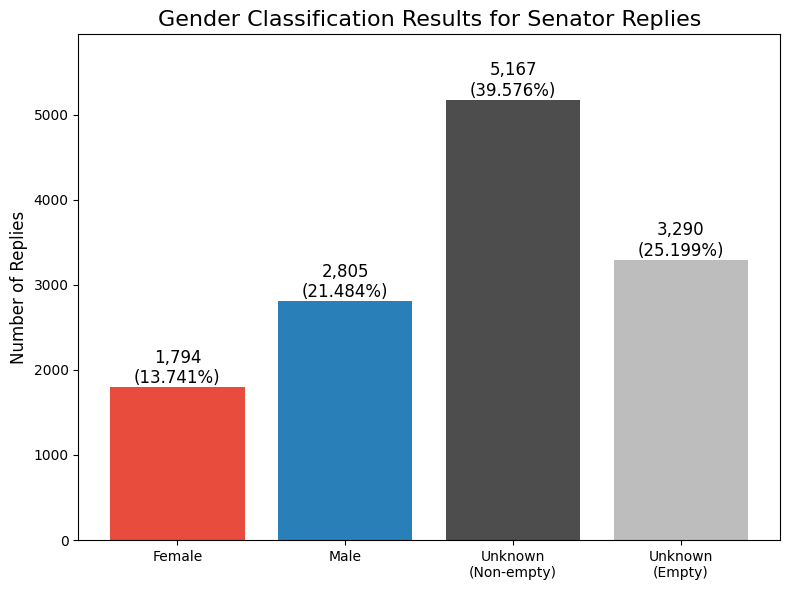

In [ ]:
# bar plot
# data
categories = ['Female', 'Male', 'Unknown\n(Non-empty)', 'Unknown\n(Empty)']
counts = [gender_counts['F'], gender_counts['M'], gender_counts['U'] - empty_display_names, empty_display_names]
percentages = [female_inferred_percent, male_inferred_percent, unknown_percent - unknown_empty_percent, unknown_empty_percent]
# create plot
plt.figure(figsize=(8, 6))
bars = plt.bar(categories, counts, color=['#E74C3C', '#2980B9', '#4D4D4D', '#BDBDBD'])
for bar, count, pct in zip(bars, counts, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{count:,}\n({pct:.3f}%)', ha='center', va='bottom', fontsize=12)
plt.ylabel('Number of Replies', fontsize=12)
plt.title('Gender Classification Results for Senator Replies', fontsize=16)
plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

In [6]:
# check the repliers we can NOT classify
ex_U = []
for senator in all_senators_replies[:5]:
    for post in senator['posts']:
        for reply in post['replies']:
            if reply.get('inferred_gender') == 'U' and reply['displayName'] != '' and len(ex_U) < 20:
                ex_U.append(reply['displayName'])
print("Examples of displayName that Can NOT be Classified:")
print(ex_U)

Examples of displayName that Can NOT be Classified:
['How You Like Me Now?...', 'AmySK', 'Just Mac 🦋', ' كريس', 'Progressive senior', 'Soulless', 'Vinegrr', 'DBdant', 'StudentEternal', 'Entomomancer', 'TrueBlueJWilly', 'GG Anderson', 'Rio', 'LoboJoven', 'CurmudgeonAtLarge', 'OldeHippi🦋', 'TheBaroness 🐸', 'Jerked Gherkins', 'J.R.', 'Digit@LsacK']


## II.3 Homophily Measurement

Measure gender patterns in replies:

1. Baseline: Across all senators, what fraction of classifiable repliers are female vs. male? Call these p_female and p_male = 1 - p_female.

2. By senator gender:
    - For female senators, what fraction of their repliers are female? Call this obs_F.
    - For male senators, what fraction of their repliers are male? Call this obs_M.

3. Homophily coefficient: Compute a measure of same-gender homophily for each senator gender:
H_female = obs_F - p_female
H_male   = obs_M - p_male

Interpretation:
- H > 0 indicates homophily: same-gender repliers are over-represented relative to baseline
- H < 0 indicates heterophily: same-gender repliers are under-represented
- H = 0 indicates no preference: replier gender matches the overall baseline
Example: If the baseline is 40% female (p_female = 0.40) and female senators receive 45% female repliers (obs_F = 0.45), then H_female = 0.45 - 0.40 = +0.05, indicating mild homophily.

Create a visualization showing the gender breakdown of repliers for female vs. male senators.

In [ ]:
# 1) baseline
# calculate the p_female and p_male
p_female = gender_counts['F'] / gender_inferred_counts
p_male = gender_counts['M'] / gender_inferred_counts
# print result
print("Baseline Fraction of Classifiable Repliers:")
print(f"   - p_female = {p_female:.3f} ({p_female*100:.3f}%)")
print(f"   - p_male   = {p_male:.3f} ({p_male*100:.3f}%)")

Baseline Fraction of Classifiable Repliers:
   - p_female = 0.390 (39.008%)
   - p_male   = 0.610 (60.992%)


In [21]:
# 2) by senator gender
female_senator_replies = {'F': 0, 'M': 0}
male_senator_replies = {'F': 0, 'M': 0}
female_senator_num = 14
male_senator_num = 28

for senator in all_senators_replies:
    senator_gender = senator['senator']['gender']
    for post in senator['posts']:
        for reply in post['replies']:
            reply_gender = reply.get('inferred_gender')
            if reply_gender == 'F' or reply_gender == 'M':
                if senator_gender == 'F':
                    female_senator_replies[reply_gender] += 1
                if senator_gender == 'M':
                    male_senator_replies[reply_gender] += 1

# calculate the obs_F and obs_M
tot_obs_F = sum(female_senator_replies.values())
tot_obs_M = sum(male_senator_replies.values())
obs_F = female_senator_replies['F'] / tot_obs_F
obs_M = male_senator_replies['M'] / tot_obs_M
# print result
print("Fraction of Classifiable Repliers (By Senator Gender):")
print(f"   - female_senator_replies = {female_senator_replies}")
print(f"   - obs_F = {obs_F:.3f} ({obs_F*100:.3f}%)")
print(f"   - male_senator_replies = {male_senator_replies}")
print(f"   - obs_M = {obs_M:.3f} ({obs_M*100:.3f}%)")

Fraction of Classifiable Repliers (By Senator Gender):
   - female_senator_replies = {'F': 516, 'M': 759}
   - obs_F = 0.405 (40.471%)
   - male_senator_replies = {'F': 1278, 'M': 2046}
   - obs_M = 0.616 (61.552%)


In [22]:
# 3) homophily coefficient
# calculate the H_female and H_male
H_female = obs_F - p_female
H_male = obs_M - p_male
print("Homophily Coefficient:")
print(f"H_female = {obs_F:.3f} - {p_female:.3f} = {H_female:.3f}")
print(f"H_male   = {obs_M:.3f} - {p_male:.3f} = {H_male:.3f}")

Homophily Coefficient:
H_female = 0.405 - 0.390 = 0.015
H_male   = 0.616 - 0.610 = 0.006


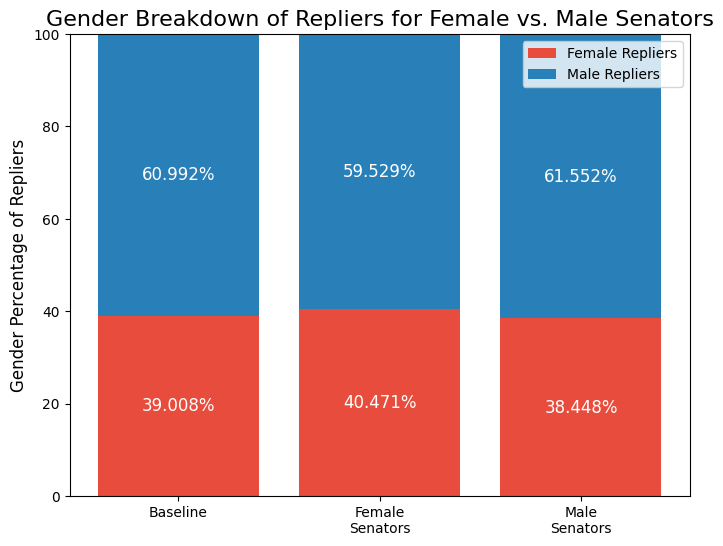

In [66]:
# 4) create a visualization showing the gender breakdown of repliers for female vs. male senators
# data
senator_types = ['Baseline', 'Female\nSenators', 'Male\nSenators']
female_percentages = [p_female * 100, obs_F * 100, (1 - obs_M) * 100]
male_percentages = [p_male * 100, (1 - obs_F) * 100, obs_M * 100]
# create plot
fig, ax = plt.subplots(figsize=(8, 6))
bars1 = plt.bar(senator_types, female_percentages, label='Female Repliers', color='#E74C3C')
bars2 = plt.bar(senator_types, male_percentages, bottom=female_percentages, label='Male Repliers', color='#2980B9')
for i, (f_pct, m_pct) in enumerate(zip(female_percentages, male_percentages)):   # add percentage labels
    plt.text(i, f_pct/2, f'{f_pct:.3f}%', ha='center', va='center', fontsize=12, color='white')
    plt.text(i, f_pct + m_pct/2, f'{m_pct:.3f}%', ha='center', va='center', fontsize=12, color='white')
plt.ylabel('Gender Percentage of Repliers', fontsize=12)
plt.title('Gender Breakdown of Repliers for Female vs. Male Senators', fontsize=16)
plt.ylim(0, 100)
plt.legend()
plt.show()

In [ ]:
# 5) statistical significance
# chi-square test
# H0: distribution of replier gender is the same for female and male senators (replier gender is independent of senator gender)
# H1: distribution of replier gender differs between female and male senators (replier gender is not independent of senator gender)

# create table for chi-square test
table_fm = np.array([[female_senator_replies['F'], female_senator_replies['M']],
                     [male_senator_replies['F'], male_senator_replies['M']]])

# run chi-square test
chi_square_stat, p_value, df, expected = stats.chi2_contingency(table_fm)
print(f"Chi-square Test Results:")
print(f"   - chi-square statistic: {chi_square_stat:.3f}")
print(f"   - degrees of freedom: {df}")
print(f"   - p-value: {p_value:.3f}")

# According to chi-square test results, we fail to reject null hypothesis.
# The distribution of replier gender is the same for female and male senators.

Chi-square Test Results:
   - chi-square statistic: 1.501
   - degrees of freedom: 1
   - p-value: 0.220


## II.4 Reply Timing Analysis

Since the API preferentially returns early replies, investigate whether early and late replies differ.

Focus on posts with 50–200 total replies (where you likely captured most replies):

1. Split replies into “early” (first 25% by timestamp) and “late” (last 25%)
2. Compare the gender composition of early vs. late replies
3. Look for other differences: reply length, engagement received (likes), or any other quantifiable patterns you observe

This analysis helps you understand the bias introduced by the API’s ~200-reply limit and reason about what you might be missing for high-engagement posts.

In [59]:
# 1) focus on posts with 50–200 total replies
posts_filtered = []
for senator in all_senators_replies:
    senator_name = senator['senator']['name']
    for post in senator['posts']:
        reply_count = post['replyCount']
        if 50 <= reply_count <= 200:
            posts_filtered.append({
                'senatorName': senator_name,
                'senatorGender': senator['senator']['gender'],
                'post': post
            })

In [60]:
# 2) split replies into “early” (first 25% by timestamp) and “late” (last 25%)
early_replies = []
late_replies = []
for p in posts_filtered:
    post = p['post']

    # sort replies by timestamp
    replies_sorted = []
    for reply in post['replies']:
        timestamp = reply.get('timestamp')
        timestamp = datetime.fromisoformat(timestamp.replace('Z', '+00:00'))
        replies_sorted.append((timestamp, reply))
    replies_sorted.sort(key=lambda x: x[0])

    # split replies into early and late
    n_replies = len(replies_sorted)
    early = round(n_replies * 0.25)
    late = round(n_replies * 0.75)
    # early (first 25% by timestamp)
    for dt, reply in replies_sorted[:early]:
        early_replies.append(reply)
    # late (last 25% by timestamp)
    for dt, reply in replies_sorted[late:]:
        late_replies.append(reply)

In [63]:
# 3) compare the gender composition of early vs. late replies
early_gender = {'F': 0, 'M': 0, 'U': 0}
late_gender = {'F': 0, 'M': 0, 'U': 0}
# count early replies' gender composition
for reply in early_replies:
    gender = reply['inferred_gender']
    early_gender[gender] += 1
# count late replies' gender composition
for reply in late_replies:
    gender = reply['inferred_gender']
    late_gender[gender] += 1

# calculate the gender composition percentage
tot_early = early_gender['F'] + early_gender['M']
tot_late = late_gender['F'] + late_gender['M']
early_F_percent = early_gender['F'] / tot_early
late_F_percent = late_gender['F'] / tot_late
# print result
print("Gender Composition of Early vs. Late Replies:")
print(f"   - early_gender = {early_gender}")
print(f"   - early replies' female percentage = {early_F_percent:.3f} ({early_F_percent*100:.3f}%)")
print(f"   - late_gender = {late_gender}")
print(f"   - late replies' female percentage = {late_F_percent:.3f} ({late_F_percent*100:.3f}%)")

Gender Composition of Early vs. Late Replies:
   - early_gender = {'F': 160, 'M': 257, 'U': 674}
   - early replies' female percentage = 0.384 (38.369%)
   - late_gender = {'F': 171, 'M': 204, 'U': 716}
   - late replies' female percentage = 0.456 (45.600%)


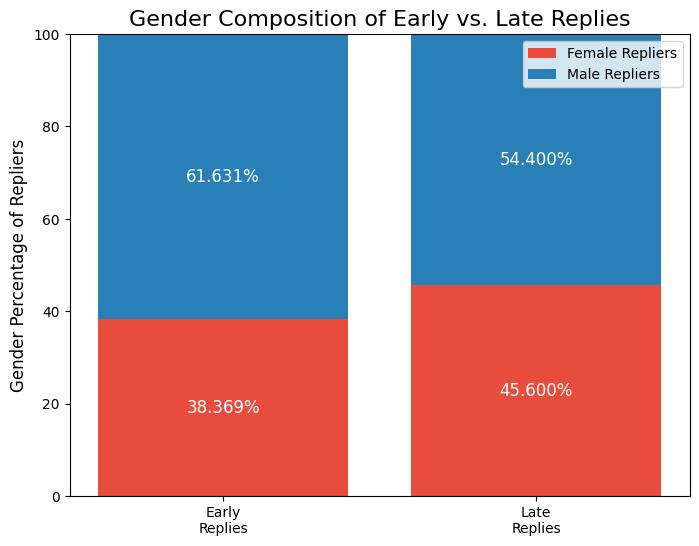

In [65]:
# create plot
# data
early_late = ['Early\nReplies', 'Late\nReplies']
female_percentages = [early_F_percent * 100, late_F_percent * 100]
male_percentages = [(1 - early_F_percent) * 100, (1 - late_F_percent) * 100]
# create plot
fig, ax = plt.subplots(figsize=(8, 6))
bars1 = plt.bar(early_late, female_percentages, label='Female Repliers', color='#E74C3C')
bars2 = plt.bar(early_late, male_percentages, bottom=female_percentages, label='Male Repliers', color='#2980B9')
for i, (f_pct, m_pct) in enumerate(zip(female_percentages, male_percentages)):   # add percentage labels
    plt.text(i, f_pct/2, f'{f_pct:.3f}%', ha='center', va='center', fontsize=12, color='white')
    plt.text(i, f_pct + m_pct/2, f'{m_pct:.3f}%', ha='center', va='center', fontsize=12, color='white')
plt.ylabel('Gender Percentage of Repliers', fontsize=12)
plt.title('Gender Composition of Early vs. Late Replies', fontsize=16)
plt.ylim(0, 100)
plt.legend()
plt.show()

In [67]:
# statistical significance for reply timing analysis
# chi-square test
# H0: distribution of replier gender is the same for early and late replies (replier gender is independent of timing)
# H1: distribution of replier gender differs between early and late replies (replier gender is not independent of timing)

# create table for chi-square test
table_el = np.array([[early_gender['F'], early_gender['M']],
                     [late_gender['F'], late_gender['M']]])

# run chi-square test
chi_square_stat, p_value, df, expected = stats.chi2_contingency(table_el)
print(f"Chi-square Test Results:")
print(f"   - chi-square statistic: {chi_square_stat:.3f}")
print(f"   - degrees of freedom: {df}")
print(f"   - p-value: {p_value:.3f}")

Chi-square Test Results:
   - chi-square statistic: 3.951
   - degrees of freedom: 1
   - p-value: 0.047


In [ ]:
# 4) compare the reply length of early vs. late replies
early_reply_lengths = [len(reply['text']) for reply in early_replies]
late_reply_lengths = [len(reply['text']) for reply in late_replies]
early_reply_lengths_mean = np.mean(early_reply_lengths)
late_reply_lengths_mean = np.mean(late_reply_lengths)
early_reply_lengths_median = np.median(early_reply_lengths)
late_reply_lengths_median = np.median(late_reply_lengths)
# print result
print(f"Early Replies:")
print(f"   - average length: {early_reply_lengths_mean:.3f} characters")
print(f"   - median length: {early_reply_lengths_median} characters")
print(f"Late Replies:")
print(f"   - average length: {late_reply_lengths_mean:.3f} characters")
print(f"   - median length: {late_reply_lengths_median} characters")

Early Replies:
   - average length: 101.842 characters
   - median length: 72.0 characters
Late Replies:
   - average length: 106.353 characters
   - median length: 77.0 characters


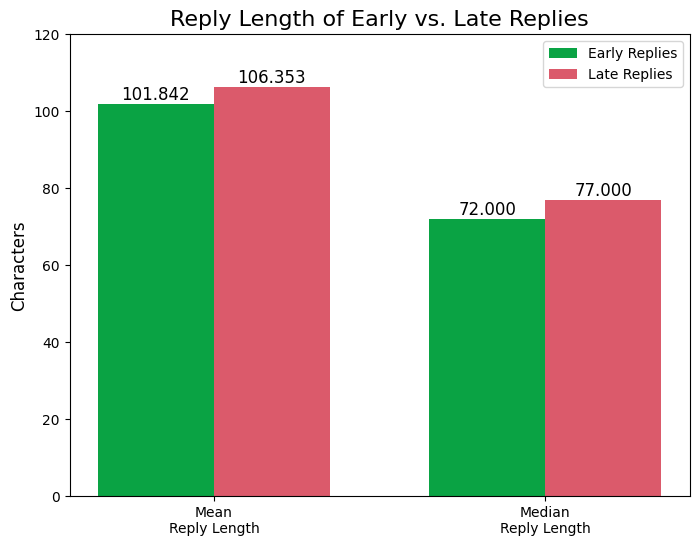

In [101]:
# create plot
# data
mean_median = ['Mean\nReply Length', 'Median\nReply Length']
early_values = [early_reply_lengths_mean, early_reply_lengths_median]
late_values = [late_reply_lengths_mean, late_reply_lengths_median]
# Create grouped bars
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(mean_median))
bars1 = ax.bar(x - 0.35/2, early_values, 0.35, label='Early Replies', color='#0AA344')
bars2 = ax.bar(x + 0.35/2, late_values, 0.35, label='Late Replies', color='#DB5A6B')
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center', va='bottom', fontsize=12)
ax.set_ylabel('Characters', fontsize=12)
ax.set_ylim(0, 120)
ax.set_title('Reply Length of Early vs. Late Replies', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(mean_median)
ax.legend()
plt.show()

In [78]:
# 5) compare the engagement received (likes) of early vs. late replies
early_reply_likes = [reply['likeCount'] for reply in early_replies]
late_reply_likes = [reply['likeCount'] for reply in late_replies]
early_reply_likes_mean = np.mean(early_reply_likes)
late_reply_likes_mean = np.mean(late_reply_likes)
early_reply_likes_median = np.median(early_reply_likes)
late_reply_likes_median = np.median(late_reply_likes)
# print result
print(f"Early Replies:")
print(f"   - average likes: {early_reply_likes_mean:.3f}")
print(f"   - median likes: {early_reply_likes_median}")
print(f"Late Replies:")
print(f"   - average likes: {late_reply_likes_mean:.3f}")
print(f"   - median likes: {late_reply_likes_median}")

Early Replies:
   - average likes: 7.451
   - median likes: 2.0
Late Replies:
   - average likes: 0.306
   - median likes: 0.0


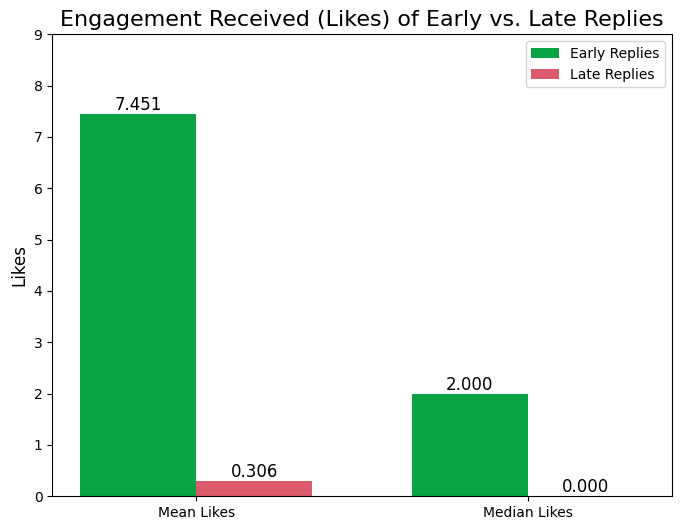

In [ ]:
# create plot
# data
mean_median_likes = ['Mean Likes', 'Median Likes']
early_values = [early_reply_likes_mean, early_reply_likes_median]
late_values = [late_reply_likes_mean, late_reply_likes_median]
# create plot
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(mean_median_likes))
bars1 = ax.bar(x - 0.35/2, early_values, 0.35, label='Early Replies', color='#0AA344')
bars2 = ax.bar(x + 0.35/2, late_values, 0.35, label='Late Replies', color='#DB5A6B')
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center', va='bottom', fontsize=12)
ax.set_ylabel('Likes', fontsize=12)
ax.set_ylim(0, 9)
ax.set_title('Engagement Received (Likes) of Early vs. Late Replies', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(mean_median_likes)
ax.legend()
plt.show()

In [ ]:
# 6) high-engagement posts
senator_info = []
for senator in all_senators_replies:
    senator_name = senator['senator']['name']
    senator_gender = senator['senator']['gender']
    total_posts_cnt = 0
    high_engagement_posts_cnt = 0
    total_posts_len = []
    high_engagement_posts_len = []
    # add values for total posts stats
    for post in senator['posts']:
        total_posts_cnt += 1
        reply_cnt = post['replyCount']
        text_tmp = post['text']
        text_len = len(text_tmp)
        total_posts_len.append(text_len)
        # add values for high-engagement posts stats
        if reply_cnt > 200:
            high_engagement_posts_cnt += 1
            high_engagement_posts_len.append(text_len)
    # calculate high-engagement posts percentage and posts length mean
    high_engagement_posts_percentage = (high_engagement_posts_cnt / total_posts_cnt) * 100 if total_posts_cnt > 0 else 0
    total_posts_len_mean = np.mean(total_posts_len) if total_posts_len else 0
    high_engagement_posts_len_mean = np.mean(high_engagement_posts_len) if high_engagement_posts_len else 0

    senator_info.append({
        'Senator': senator_name,
        'Gender': senator_gender,
        'TotalPosts': total_posts_cnt,
        'HighEngagementPosts': high_engagement_posts_cnt,
        'HighEngagementPostsPercent': high_engagement_posts_percentage,
        'PostsLengthMean': total_posts_len_mean,
        'HighEngagementPostsLengthMean': high_engagement_posts_len_mean,
    })
high_engagement_df = pd.DataFrame(senator_info)
high_engagement_df = high_engagement_df.sort_values('HighEngagementPosts', ascending=False)

# print results
print(f"Total High-engagement Posts (>200 replies): {high_engagement_df['HighEngagementPosts'].sum()}")
print(f"Senators have High-engagement Post: {(high_engagement_df['HighEngagementPosts'] > 0).sum()}")
high_engagement_df

Total High-engagement Posts (>200 replies): 14
Senators have High-engagement Post: 8


,Senator,Gender,TotalPosts,HighEngagementPosts,HighEngagementPostsPercent,PostsLengthMean,HighEngagementPostsLengthMean
35,Chris Murphy,M,10,4,40.000000,231.600000,243.750000
11,Chuck Schumer,M,22,3,13.636364,211.454545,188.666667
21,Elissa Slotkin,F,46,2,4.347826,206.478261,209.500000
3,Mark Warner,M,23,1,4.347826,164.304348,165.000000
19,Tina Smith,F,11,1,9.090909,203.090909,247.000000
20,Amy Klobuchar,F,17,1,5.882353,190.235294,63.000000
24,Ed Markey,M,58,1,1.724138,170.758621,149.000000
38,Adam Schiff,M,29,1,3.448276,228.068966,226.000000
36,Richard Blumenthal,M,11,0,0.000000,195.909091,0.000000
40,Mark Kelly,M,12,0,0.000000,214.500000,0.000000


(AI was used to improve code efficiency and assist with adding visualization details)